In [53]:
"""
Compute monthly climatologies on a fixed depth grid for the BIOS-SCOPE biogeochemical survey dataset.

This module processes the ``survey_biogeochemical.csv`` file from the
BIOS-SCOPE project and produces an ``xarray.Dataset`` containing the
mean value of each biogeochemical variable for each calendar month and
depth.  It follows the same approach as the BATS bottle climatology
script but uses a variable mapping specific to the BIOS-SCOPE survey
data.

Workflow
========

1. **Load the dataset** using ``pandas.read_csv``.  The dataset can be
   loaded from a local path or an HTTP(S) URL; remote files are read
   directly by pandas.
2. **Preprocess** the data by parsing the ``ISO_DateTime_UTC`` column
   into a datetime, extracting the month, converting depths to numeric
   and snapping them to a standard grid, converting each selected
   variable to numeric, applying quality flags where provided, and
   retaining only rows with at least one valid measurement.
3. **Aggregate** by month and depth to compute the mean for each
   variable.
4. **Assemble** the climatology into an ``xarray.Dataset`` with
   coordinates ``month`` and ``depth``.  All variables share the same
   grid and missing combinations are filled with ``NaN``.

The default depth grid spans 0–4000 m in 10 m increments to cover
the full sampling range of the BIOS-SCOPE casts.

Example usage::

    from bioscope_climatology import build_bioscope_climatology

    ds = build_bioscope_climatology(
        'survey_biogeochemical.csv'
    )
    print(ds)
    ds.to_netcdf('bioscope_monthly_climatology.nc')

"""

from __future__ import annotations

import io
import warnings
from typing import Dict, Optional

import numpy as np
import pandas as pd
import requests
import xarray as xr
import os
wrkdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(wrkdir)
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations'

In [54]:
# Mapping of raw column names to simplified output names.  Only these
# variables will be processed and included in the climatology.
VARIABLES: Dict[str, str] = {
    'Temp': 'temperature',
    'CTD_SBE35T': 'temperature_sbe35',
    'Conductivity': 'conductivity',
    'CTD_S': 'salinity_ctd',
    'Pressure': 'pressure',
    'sig_theta': 'sigma_theta',
    'O2': 'oxygen',
    'BAC': 'beam_attenuation',
    'Fluo': 'fluorescence',
    'PAR': 'par',
    'Pot_Temp': 'potential_temperature',
    'Niskin_temp': 'niskin_temperature',
    'NO3_plus_NO2': 'nitrate_plus_nitrite',
    'NO3': 'nitrate',
    'NO2': 'nitrite',
    'PO4': 'phosphate',
    'NH4': 'ammonium',
    'SiO2': 'silicate',
    'POC': 'poc',
    'PON': 'pon',
    'DOC': 'doc',
    'TDN': 'tdn',
    'Bact': 'bacteria_abundance',
    'BP_Leu': 'bacterial_production_leucine',
    'TDAA': 'tdaa',
    'Ala': 'alanine',
    'Arg': 'arginine',
    'Asp': 'aspartic_acid',
    'Beta_Ala': 'beta_alanine',
    'GABA': 'gaba',
    'Glu': 'glutamic_acid',
    'Gly': 'glycine',
    'His': 'histidine',
    'Ile': 'isoleucine',
    'Leu': 'leucine',
    'Lys': 'lysine',
    'Met': 'methionine',
    'Phe': 'phenylalanine',
    'Ser': 'serine',
    'Tau': 'taurine',
    'Thr': 'threonine',
    'Tyr': 'tyrosine',
    'Val': 'valine',
}

# Quality flag columns corresponding to the above variables.  If a flag
# column exists, only values with flag values 1 or 2 will be used.
FLAG_COLUMNS: Dict[str, str] = {
    'nitrate_plus_nitrite': 'NO3_plus_NO2_QF',
    'nitrate': 'NO3_QF',
    'nitrite': 'NO2_QF',
    'phosphate': 'PO4_QF',
    'ammonium': 'NH4_QF',
    'silicate': 'SiO2_QF',
    'poc': 'POC_QF',
    'pon': 'PON_QF',
    'doc': 'DOC_QF',
    'tdn': 'TDN_QF',
    'bacteria_abundance': 'Bact_QF',
    'bacterial_production_leucine': 'BP_Leu_QF',
    'tdaa': 'TDAA_QF',
    # amino acid quality flags are not provided individually, so all values are used
}
FLAG_COLUMNS: Dict[str, str] = {
}


# Units for each variable.  These are based on the dataset metadata.
UNITS: Dict[str, Optional[str]] = {
    'temperature': 'degree_Celsius',
    'temperature_sbe35': 'degree_Celsius',
    'conductivity': 'Siemens_per_meter',
    'salinity_ctd': 'PSU',
    'pressure': 'decibar',
    'sigma_theta': 'kg_per_m3',
    'oxygen': 'micromole_per_kg',
    'beam_attenuation': '1_per_meter',
    'fluorescence': 'microgram_per_liter',
    'par': 'microEinstein_per_m2_per_s',
    'potential_temperature': 'degree_Celsius',
    'niskin_temperature': 'degree_Celsius',
    'nitrate_plus_nitrite': 'micromole_per_kg',
    'nitrate': 'micromole_per_kg',
    'nitrite': 'micromole_per_kg',
    'phosphate': 'micromole_per_kg',
    'ammonium': 'micromole_per_kg',
    'silicate': 'micromole_per_kg',
    'poc': 'microgram_per_kg',
    'pon': 'microgram_per_kg',
    'doc': 'micromole_per_kg',
    'tdn': 'micromole_per_kg',
    'bacteria_abundance': 'cells_1e8_per_kg',
    'bacterial_production_leucine': 'pmol_per_l_per_hr',
    'tdaa': 'nanomole_per_l',
    'alanine': 'nanomole_per_l',
    'arginine': 'nanomole_per_l',
    'aspartic_acid': 'nanomole_per_l',
    'beta_alanine': 'nanomole_per_l',
    'gaba': 'nanomole_per_l',
    'glutamic_acid': 'nanomole_per_l',
    'glycine': 'nanomole_per_l',
    'histidine': 'nanomole_per_l',
    'isoleucine': 'nanomole_per_l',
    'leucine': 'nanomole_per_l',
    'lysine': 'nanomole_per_l',
    'methionine': 'nanomole_per_l',
    'phenylalanine': 'nanomole_per_l',
    'serine': 'nanomole_per_l',
    'taurine': 'nanomole_per_l',
    'threonine': 'nanomole_per_l',
    'tyrosine': 'nanomole_per_l',
    'valine': 'nanomole_per_l',
}

# Default depth grid: 0–4000 m in 10 m increments.
DEFAULT_DEPTH_GRID: np.ndarray = np.arange(0.0, 300.0 + 1.0, 20.0)

# Default allowable deviation (in meters) when snapping depths to the grid.
DEFAULT_DEPTH_TOLERANCE: float = 10.0


### DOWNLOAD

In [55]:
def load_bioscope_data(path_or_url: str) -> pd.DataFrame:
    """Load the BIOS-SCOPE survey CSV into a DataFrame.

    Parameters
    ----------
    path_or_url : str
        Local path or HTTP(S) URL to the CSV file.

    Returns
    -------
    pandas.DataFrame
        The loaded DataFrame.
    """
    if path_or_url.startswith(('http://', 'https://')):
        # Let pandas handle remote URLs directly.  If this fails,
        # download manually to a buffer.
        try:
            return pd.read_csv(path_or_url)
        except Exception:
            resp = requests.get(path_or_url)
            resp.raise_for_status()
            return pd.read_csv(io.BytesIO(resp.content))
    else:
        return pd.read_csv(path_or_url)

### PROCESS

In [56]:
def preprocess_bioscope(
    df: pd.DataFrame,
    depth_grid: Optional[np.ndarray] = None,
    depth_tolerance: float = DEFAULT_DEPTH_TOLERANCE,
) -> pd.DataFrame:
    """Preprocess the BIOS-SCOPE DataFrame for climatology.

    This includes date parsing, depth snapping, quality flag filtering and
    conversion of variables to numeric types.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw BIOS-SCOPE dataset.
    depth_grid : numpy.ndarray, optional
        Depth grid onto which measurements are binned.  If not
        provided, ``DEFAULT_DEPTH_GRID`` is used.
    depth_tolerance : float, optional
        Maximum absolute difference allowed between the original depth
        and the nearest grid point for inclusion.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the columns ``month``, ``depth`` and
        one column per selected variable.  Rows where all selected
        variables are missing are dropped.
    """
    if df.empty:
        return df
    if depth_grid is None:
        depth_grid = DEFAULT_DEPTH_GRID
    # Parse datetime
    if 'ISO_DateTime_UTC' not in df.columns:
        raise ValueError("Missing 'ISO_DateTime_UTC' column.")
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['ISO_DateTime_UTC'], errors='coerce')
    df.dropna(subset=['datetime'], inplace=True)
    df['month'] = df['datetime'].dt.month.astype(int)
    # Depth processing
    if 'Depth' not in df.columns:
        raise ValueError("Missing 'Depth' column.")
    df['depth_orig'] = pd.to_numeric(df['Depth'], errors='coerce')
    df.dropna(subset=['depth_orig'], inplace=True)
    # Snap to nearest grid level
    idxs = np.abs(df['depth_orig'].values[:, None] - depth_grid[None, :]).argmin(axis=1)
    snapped = depth_grid[idxs]
    within = np.abs(df['depth_orig'] - snapped) <= depth_tolerance
    df = df.loc[within].copy()
    df['depth'] = snapped[within.values]
    # Convert variables and apply quality flags
    present_vars: list[str] = []
    for raw_name, out_name in VARIABLES.items():
        if raw_name not in df.columns:
            continue
        series = pd.to_numeric(df[raw_name], errors='coerce')
        # Apply flag if available
        flag_col = FLAG_COLUMNS.get(out_name)
        if flag_col is not None and flag_col in df.columns:
            good = df[flag_col].isin([1, 2])
            series = series.where(good)
        if series.notna().any():
            df[out_name] = series
            present_vars.append(out_name)
    if not present_vars:
        warnings.warn("No selected variables found in BIOS-SCOPE data.")
        return pd.DataFrame()
    df.dropna(subset=present_vars, how='all', inplace=True)
    return df[['month', 'depth'] + present_vars]


### CLIMATOLOGY

In [57]:
def compute_monthly_climatology(df: pd.DataFrame) -> pd.DataFrame:
    """Group by month and depth and compute means for all variables."""
    if df.empty:
        return df
    grouped = df.groupby(['month', 'depth'], as_index=True)
    clim = grouped.mean(numeric_only=True)
    clim.sort_index(inplace=True)
    return clim

### BUILD

In [58]:
def build_bioscope_climatology(
    path_or_url: str,
    depth_grid: Optional[np.ndarray] = None,
    depth_tolerance: float = DEFAULT_DEPTH_TOLERANCE,
) -> xr.Dataset:
    """Compute a monthly climatology for the BIOS-SCOPE survey dataset.

    Parameters
    ----------
    path_or_url : str
        Path or URL to the ``survey_biogeochemical.csv`` file.
    depth_grid : numpy.ndarray, optional
        Depth grid for binning; defaults to ``DEFAULT_DEPTH_GRID``.
    depth_tolerance : float, optional
        Allowed depth deviation when snapping to the grid.

    Returns
    -------
    xarray.Dataset
        Dataset containing monthly mean profiles of all selected variables.
    """
    raw_df = load_bioscope_data(path_or_url)
    tidy = preprocess_bioscope(raw_df, depth_grid=depth_grid, depth_tolerance=depth_tolerance)
    if tidy.empty:
        return xr.Dataset()
    clim_df = compute_monthly_climatology(tidy)
    # Determine full set of months (1–12) and depths for dataset dimensions
    all_months = np.arange(1, 13)
    depths = depth_grid if depth_grid is not None else DEFAULT_DEPTH_GRID
    ds = xr.Dataset()
    # Unstack MultiIndex to 2D table [depth x month] for each variable
    unstacked = clim_df.unstack(level=0)
    for var in unstacked.columns.get_level_values(0).unique():
        var_df = unstacked[var]
        # Reindex depth and month to full axes
        var_df = var_df.reindex(index=depths, columns=all_months, fill_value=np.nan)
        data = var_df.values.astype(float)
        ds[var] = xr.DataArray(
            data,
            coords={'depth': depths, 'month': all_months},
            dims=['depth', 'month'],
            name=var,
            attrs={'units': UNITS.get(var)}
        )
    ds['depth'].attrs['units'] = 'meters'
    ds['month'].attrs['long_name'] = 'Calendar month'
    return ds


### call

In [59]:
%%time

link = "https://datadocs.bco-dmo.org/dataset/861266/file/KAAGNEBc2V61jx/survey_biogeochemical.csv"
ds = build_bioscope_climatology(link)
print(ds)


<xarray.Dataset> Size: 59kB
Dimensions:                       (depth: 16, month: 12)
Coordinates:
  * depth                         (depth) float64 128B 0.0 20.0 ... 280.0 300.0
  * month                         (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/38)
    temperature                   (depth, month) float64 2kB nan nan ... nan nan
    temperature_sbe35             (depth, month) float64 2kB nan nan ... nan nan
    conductivity                  (depth, month) float64 2kB nan nan ... nan nan
    salinity_ctd                  (depth, month) float64 2kB nan nan ... nan nan
    pressure                      (depth, month) float64 2kB nan nan ... nan nan
    sigma_theta                   (depth, month) float64 2kB nan nan ... nan nan
    ...                            ...
    methionine                    (depth, month) float64 2kB nan nan ... nan nan
    serine                        (depth, month) float64 2kB nan nan ... nan nan
    taurine                     

In [60]:
ds.data_vars

Data variables:
    temperature                   (depth, month) float64 2kB nan nan ... nan nan
    temperature_sbe35             (depth, month) float64 2kB nan nan ... nan nan
    conductivity                  (depth, month) float64 2kB nan nan ... nan nan
    salinity_ctd                  (depth, month) float64 2kB nan nan ... nan nan
    pressure                      (depth, month) float64 2kB nan nan ... nan nan
    sigma_theta                   (depth, month) float64 2kB nan nan ... nan nan
    oxygen                        (depth, month) float64 2kB nan nan ... nan nan
    beam_attenuation              (depth, month) float64 2kB nan nan ... nan nan
    fluorescence                  (depth, month) float64 2kB nan nan ... nan nan
    par                           (depth, month) float64 2kB nan nan ... nan nan
    potential_temperature         (depth, month) float64 2kB nan nan ... nan nan
    niskin_temperature            (depth, month) float64 2kB nan nan ... nan nan
    nitrate_

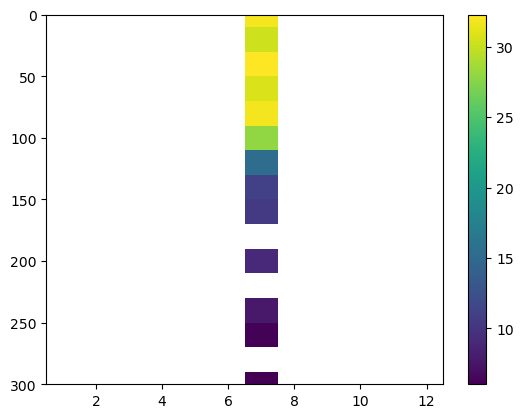

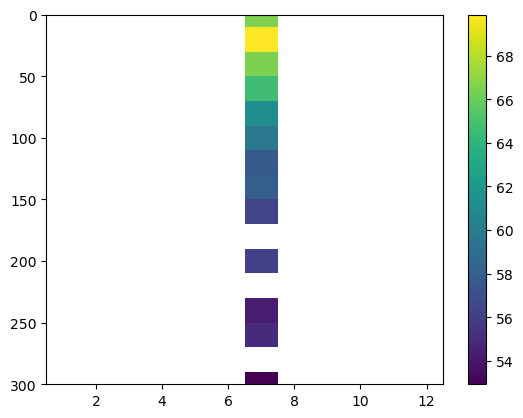

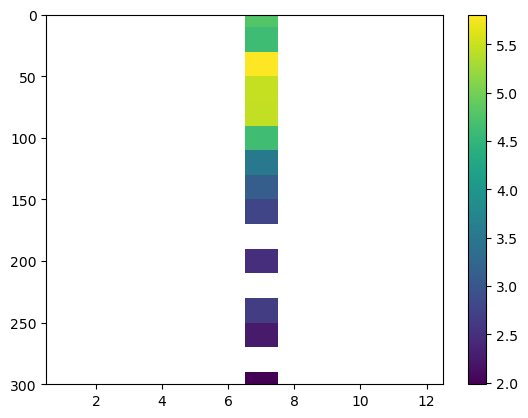

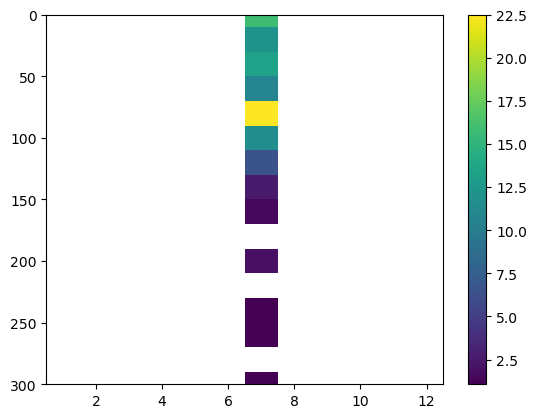

In [62]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['poc'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['doc'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['bacteria_abundance'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['bacterial_production_leucine'])
plt.ylim(300,0)
plt.colorbar()

### SAVE

In [63]:
%%time
    
ds.to_netcdf('./bats_bioscope_monthly_climatology.nc')

CPU times: user 345 ms, sys: 182 ms, total: 527 ms
Wall time: 2.98 s
